<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/nprivaul/fractionalpdes/blob/master/fujita-type.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

This code solves the time-fractional Fujita-type equation 
$$\partial_t^\alpha u=-(-\Delta u)^{\gamma/2}+\lambda (p_0+p_1 u+\cdots +p_N u^N)$$ 
on the whole space $\mathbb{R}^2$ with initial condition $f$, $\lambda>0$, $p_k\in [0,1]$, $p_0+\cdots +p_N=1$ and $(\alpha , \gamma) = (0.5,0.5)$ or $(\alpha , \gamma ) = ( 0.5,2/3)$.

In [1]:
import math
import matplotlib.pyplot as plt
from scipy.stats import expon,uniform,norm
import numpy as np
from scipy.special import gammaln
import time
from multiprocessing import Pool

plt.rcParams.update({
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 16,
    "legend.title_fontsize": 14,
    "xtick.major.pad": 8,        # Increase distance between x-axis and tick labels (default ~4)
    "figure.titlesize": 24,
    "axes.xmargin": 0,      # Equivalent to ax.margins(x=0)
    "figure.autolayout": True,  # Equivalent to plt.tight_layout()
})

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Thu Feb 26 19:50:07 2026

@author: gerar
"""

#=============================================================================
#MC ALGORITHM
#=============================================================================
def f(x,d,gamma): 
    """
    Initial condition - a function from R^d to [0,1]
    x=[x[1],...,x[d]] is an array if d>1; if d=1, x must be a float
    This initial condition leads to a stationary solution, useful for comparing the MC algorithm
    """
    A=1
    c=[0 for i in range(d)]
    normx=np.linalg.norm(np.array(x)-np.array(c))
    log_ratio=gammaln((d-gamma)/2)-gammaln((d+gamma)/2)
    ratio=np.exp(log_ratio/gamma)
    return A*(1.0+(0.5*A**(2/(d-gamma))*normx*ratio)**2)**((gamma-d)/2) 

def subordinator_rv(alpha):
    """
    This simulates S(1), where (S(t))_t is an \alpha-stable subordinator (Chambers, Mallows, Stuck (1976))
    alpha is a number in (0,1]
    """
    if alpha==1:
        return 1
    else:
        theta=math.pi*uniform.rvs()
        w=expon.rvs()
        aux1=math.sin((1-alpha)*theta)*(math.sin(alpha*theta))**(alpha/(1-alpha))
        aux2=(math.sin(theta))**(1/(1-alpha))
        aux3=aux1/aux2
        return (aux3/w)**((1-alpha)/alpha)
    
def stable_rv(gamma,d,t):
    """
    This simulates X(t), where (X(t))_t is a d-dimensional symmetric gamma-stable process
    gamma is a number in (0,2], d is a natural number, t geq 0
    If d==1, the output is a float; if d>1, it is an array 
    """
    if d==1:
        return norm.rvs()*(2*subordinator_rv(gamma/2))**(1/2)*t**(1/gamma)  #Scaling property
    else:
        aux1=norm.rvs(size=d)
        aux2=subordinator_rv(gamma/2)
    return [aux1[i]*(2*aux2)**(1/2)*t**(1/gamma) for i in range(d)]
   
def discrete_rv(p):
    """
    This simulates a random variable on {0,1,..., N}, N>1, according to law [p_0,p_1,...,p_N]
    p_k is a number in [0,1] and p_0+p_1+...+p_N=1
    """
    aux=0
    u=uniform.rvs()
    for i in range(len(p)):
        if u<aux+p[i]:
            return i
        else:
            aux=aux+p[i]

def branching(alpha,gamma,lam,p,d,x,T):
    """
    This simulates the random variable U=e^{lambda W_t^alpha} prod_{k in mathcal{N}_t^alpha}f(x+Y_k^alpha(t))
    alpha,gam,lam,p,d are as in "PARAMETERS"
    x=[x[1],...,x[d]] is an array representing a point, T is a positive number representing time
    """
    s1=subordinator_rv(alpha)
    tau=expon.rvs()/lam                             #Exponential lifetime 
    sigma=s1*tau**(1/alpha)                         #Mittag Leffler lifetime
    if sigma>T:                                     #No branching case
        et=(T/s1)**alpha                            #Inverse stable subordinator law
        dx=stable_rv(gamma,d,et)                    #Spatial displacement
        if d==1:                                    #Dimension one case
            Y=x+dx                                  #Position at branching time
            return f(Y,d,gamma)*math.exp(lam*et)
        else:                                       #Dimension greater than one
            Y=[x[i]+dx[i] for i in range(d)]
            return f(Y,d,gamma)*math.exp(lam*et)
    else:                                           #Branching case
        branches=discrete_rv(p)                     #Number of branches
        aux=math.exp(lam*tau)
        dx=stable_rv(gamma,d,tau)                   
        if d==1:
            Y=x+dx
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma)    #Recursion
            return aux 
        else:
            Y=[x[i]+dx[i] for i in range(d)]
            for i in range(branches):
                aux=aux*branching(alpha,gamma,lam,p,d,Y,T-sigma) 
            return aux
            
def mc_fujita_sol(alpha,gamma,lam,p,d,x,T,n_iter):   
    """
    This is the Monte Carlo estimator of the solution at (x,T)
    alpha,gam,lam,p,d are as in the section "Parameters"
    n_iter is the sample size
    """                      
    aux=0
    for i in range(n_iter):
        aux=aux+branching(alpha,gamma,lam,p,d,x,T)
    return aux/n_iter               #MC estimator



Running 1D case...
Using 8 CPU cores for 41 points with 1000 iterations each...
Time = 33.82 seconds


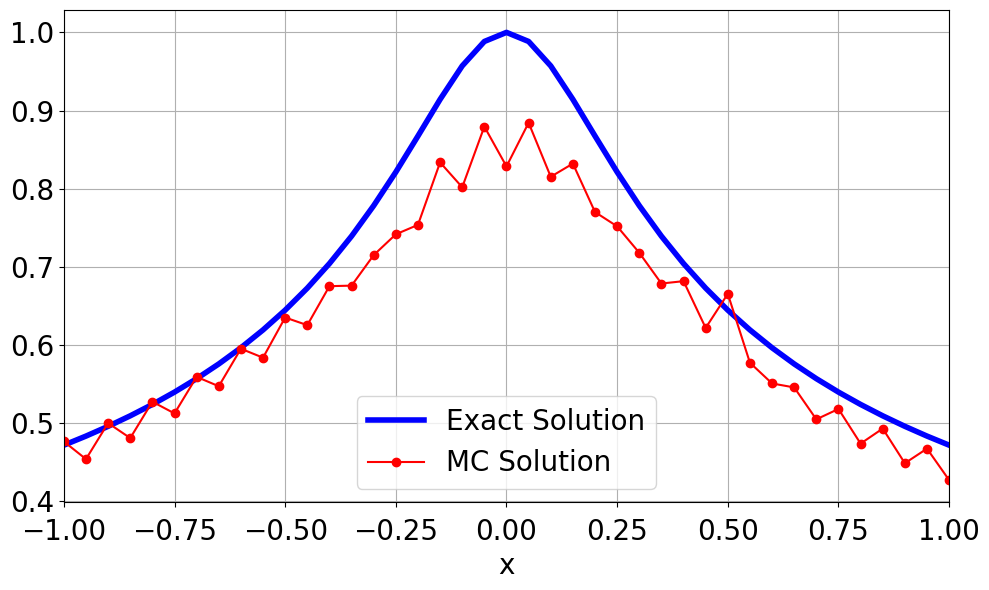

In [3]:
#==============================================================================
#Example - one dimensional case with multiprocessing
#==============================================================================
import numpy as np
import time
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count
from functools import partial

print("Running 1D case...")
start = time.time()        

#PARAMETERS
alpha = 0.5
lam = 1
d = 1
gamma = 1/2
p = [0, 0, 0, 1] 
n_iter = 1000
T = 0.5
a = -1      
b = 1
nx1 = 41

#Space discretization
x_1d = [a + i*(b-a)/(nx1-1) for i in range(nx1)]    #Space discretization

# Create a function that will be called for each x value
def compute_mc_solution(x, alpha, gamma, lam, p, d, T, n_iter):
    """Wrapper function for mc_fujita_sol to use with multiprocessing"""
    return mc_fujita_sol(alpha, gamma, lam, p, d, x, T, n_iter)

# Prepare for multiprocessing
print(f"Using {cpu_count()} CPU cores for {len(x_1d)} points with {n_iter} iterations each...")

# Create a partial function with fixed parameters
compute_func = partial(compute_mc_solution, alpha=alpha, gamma=gamma, lam=lam, 
                       p=p, d=d, T=T, n_iter=n_iter)

# Execute in parallel using multiprocessing
with Pool(processes=cpu_count()) as pool:
    y_1d = pool.map(compute_func, x_1d)

# Convert to numpy array if needed
y_1d = np.array(y_1d)

#Initial condition for comparison
initial_1d = [f(x_1d[i], d, gamma) for i in range(len(x_1d))]

# if not os.path.isdir('logs/'):
#    os.makedirs('logs/')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_1d, initial_1d,label='Exact Solution',color='blue',linestyle='-',lw=4)
ax.plot(x_1d,y_1d,linestyle='-',marker='.',color='red',markersize=12,label='MC Solution',lw=1.5)
ax.set_xlabel("x")
ax.margins(x=0)
ax.legend(loc="lower center", fontsize=20)
plt.tight_layout()
# ax.set_xticks(xx_arr)
ax.grid(True)
fig.savefig("fujita_d1.pdf", bbox_inches="tight")

#Plot 1D results
#plt.figure(figsize=(10, 6))
#plt.plot(x_1d, initial_1d, 'r--', label='Initial condition', linewidth=2)
#plt.plot(x_1d, y_1d, 'b-', label='MC solution', linewidth=2)
#plt.title(f"1D Time-Fractional F-KPP Equation\n" rf"$\alpha={alpha}, \gamma={gamma}, \lambda={lam}, t={T}$")
#plt.xlabel(r"$x$")
#plt.legend()
#plt.grid(True, alpha=0.3)
#plt.savefig('fujita_d1.png', format='png', dpi=150)
#plt.show()

print(f"Time = {time.time() - start:.2f} seconds")

Running d=5 case...
Using 8 CPU cores for 41 points with 1000 iterations each...

Computing ordered results...
Progress: 1/41 (2.4%)
Progress: 2/41 (4.9%)
Progress: 3/41 (7.3%)
Progress: 4/41 (9.8%)
Progress: 5/41 (12.2%)
Progress: 6/41 (14.6%)
Progress: 7/41 (17.1%)
Progress: 8/41 (19.5%)
Progress: 9/41 (22.0%)
Progress: 10/41 (24.4%)
Progress: 11/41 (26.8%)
Progress: 12/41 (29.3%)
Progress: 13/41 (31.7%)
Progress: 14/41 (34.1%)
Progress: 15/41 (36.6%)
Progress: 16/41 (39.0%)
Progress: 17/41 (41.5%)
Progress: 18/41 (43.9%)
Progress: 19/41 (46.3%)
Progress: 20/41 (48.8%)
Progress: 21/41 (51.2%)
Progress: 22/41 (53.7%)
Progress: 23/41 (56.1%)
Progress: 24/41 (58.5%)
Progress: 25/41 (61.0%)
Progress: 26/41 (63.4%)
Progress: 27/41 (65.9%)
Progress: 28/41 (68.3%)
Progress: 29/41 (70.7%)
Progress: 30/41 (73.2%)
Progress: 31/41 (75.6%)
Progress: 32/41 (78.0%)
Progress: 33/41 (80.5%)
Progress: 34/41 (82.9%)
Progress: 35/41 (85.4%)
Progress: 36/41 (87.8%)
Progress: 37/41 (90.2%)
Progress: 38/4

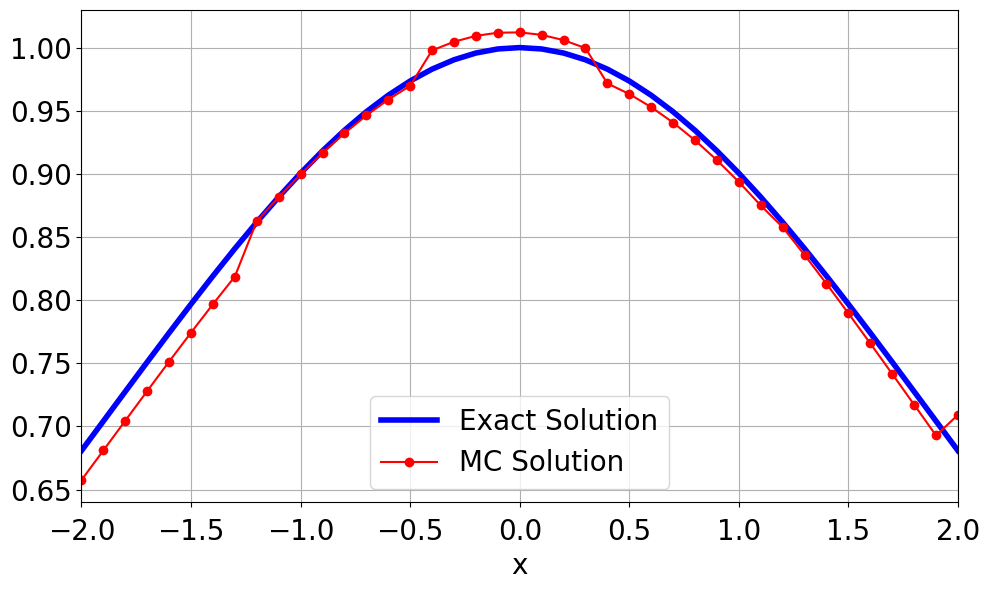

In [4]:
#==============================================================================
#EXAMPLE DIMENSION d=5 with multiprocessing and progress tracking
#==============================================================================
import numpy as np
import time
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count
from functools import partial

print("Running d=5 case...")
start = time.time()

#PARAMETERS
alpha = 0.75
lam = 1
d = 5
gamma = 5/3
p = [0, 0, 1] 
n_iter = 1000
T = 0.5
a = -2       
b = 2
nx1 = 41      

#Space discretization
x1 = [a + i*(b-a)/(nx1-1) for i in range(nx1)]     #Space discretization on axis x_1
x = [[x1[i], 0, 0, 0, 0] for i in range(nx1)]      #Selection of points on R^d

# Create a wrapper function for imap
def compute_for_point(point, alpha, gamma, lam, p, d, T, n_iter):
    return mc_fujita_sol(alpha, gamma, lam, p, d, point, T, n_iter)

# Create partial function with fixed parameters
compute_func = partial(compute_for_point, alpha=alpha, gamma=gamma, lam=lam, 
                       p=p, d=d, T=T, n_iter=n_iter)

print(f"Using {cpu_count()} CPU cores for {nx1} points with {n_iter} iterations each...")

# MC estimator using multiprocessing with progress tracking
#y1 = []
#with Pool(processes=cpu_count()) as pool:
#    results = pool.imap_unordered(compute_func, x)
#    
#    for i, result in enumerate(results):
#        y1.append(result)
#        print(f"Progress: {i+1}/{nx1} ({(i+1)/nx1*100:.1f}%)")

# Ensure order is correct (imap_unordered doesn't preserve order)
# We need to sort if order matters - but for this case, we can use imap instead
# Let's redo with order preservation:

print("\nComputing ordered results...")
y1_ordered = [0] * nx1
with Pool(processes=cpu_count()) as pool:
    results = pool.imap(compute_func, x)  # imap preserves order
    for i, result in enumerate(results):
        y1_ordered[i] = result
        print(f"Progress: {i+1}/{nx1} ({(i+1)/nx1*100:.1f}%)")

y1 = y1_ordered

# Initial condition for comparison
initial_condition = [f(x[i], d, gamma) for i in range(nx1)]
error = max([abs(y1[i] - initial_condition[i]) for i in range(nx1)])

print(f"\nError = {error:.6f}")

#Plot results
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x1, initial_condition,label='Exact Solution',color='blue',linestyle='-',lw=4)
ax.plot(x1,y1,linestyle='-',marker='.',color='red',markersize=12,label='MC Solution',lw=1.5)
ax.set_xlabel("x")
ax.margins(x=0)
ax.legend(loc="lower center", fontsize=20)
plt.tight_layout()
# ax.set_xticks(xx_arr)
ax.grid(True)
fig.savefig("fujita_d5.pdf", bbox_inches="tight")

#plt.figure(figsize=(10, 6))
#plt.plot(x1, initial_condition, 'r--', label='Exact solution', linewidth=2)
#plt.plot(x1, y1, 'b-', label='MC solution', linewidth=2)
#plt.xlabel(r"$x_1$")
#plt.legend()
#plt.grid(True, alpha=0.3)
#plt.savefig('fujita_d5.png', format='png', dpi=150)
#plt.show()

print(f"Time = {time.time() - start:.2f} seconds")

Running d=6 case...
Using 8 CPU cores for 41 points with 1000 iterations each...
Progress: 1/41 (2.4%)
Progress: 2/41 (4.9%)
Progress: 3/41 (7.3%)
Progress: 4/41 (9.8%)
Progress: 5/41 (12.2%)
Progress: 6/41 (14.6%)
Progress: 7/41 (17.1%)
Progress: 8/41 (19.5%)
Progress: 9/41 (22.0%)
Progress: 10/41 (24.4%)
Progress: 11/41 (26.8%)
Progress: 12/41 (29.3%)
Progress: 13/41 (31.7%)
Progress: 14/41 (34.1%)
Progress: 15/41 (36.6%)
Progress: 16/41 (39.0%)
Progress: 17/41 (41.5%)
Progress: 18/41 (43.9%)
Progress: 19/41 (46.3%)
Progress: 20/41 (48.8%)
Progress: 21/41 (51.2%)
Progress: 22/41 (53.7%)
Progress: 23/41 (56.1%)
Progress: 24/41 (58.5%)
Progress: 25/41 (61.0%)
Progress: 26/41 (63.4%)
Progress: 27/41 (65.9%)
Progress: 28/41 (68.3%)
Progress: 29/41 (70.7%)
Progress: 30/41 (73.2%)
Progress: 31/41 (75.6%)
Progress: 32/41 (78.0%)
Progress: 33/41 (80.5%)
Progress: 34/41 (82.9%)
Progress: 35/41 (85.4%)
Progress: 36/41 (87.8%)
Progress: 37/41 (90.2%)
Progress: 38/41 (92.7%)
Progress: 39/41 (95.

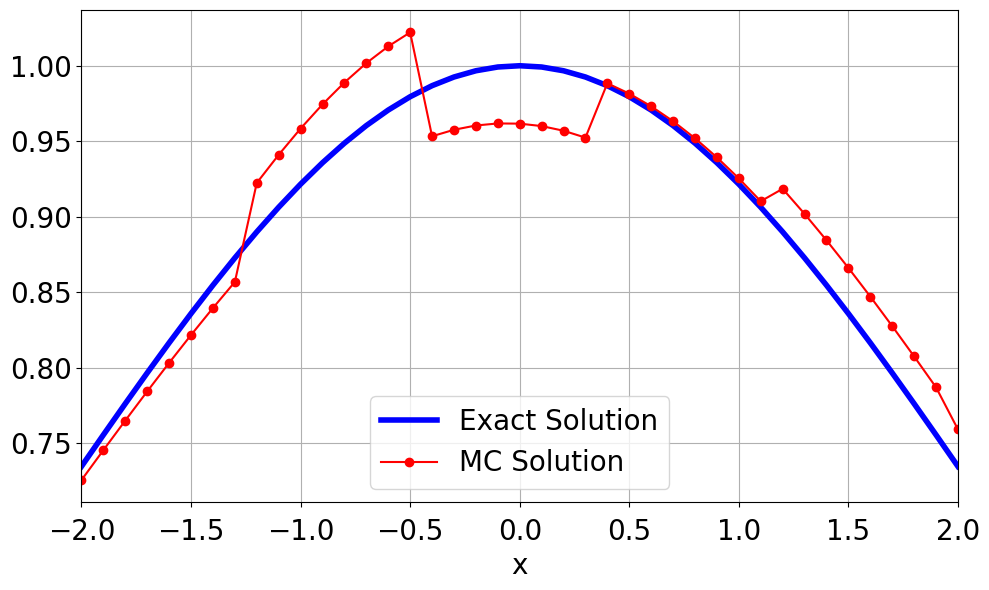

In [5]:
#==============================================================================
#EXAMPLE DIMENSION d=6 with multiprocessing and progress tracking
#==============================================================================
import numpy as np
import time
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count
from functools import partial

print("Running d=6 case...")
start = time.time()

#PARAMETERS
alpha = 0.5   #time fractional order - a number in (0,1]
lam = 1       #\lambda - a positive number
d = 6         #dimension - a natural number (d=6 in this example)
gamma = 2     #space fractional order- a number in (0,2]
p = [0, 0, 1]   #probability measure - p_k\in [0,1], p_0+...+p_n=1
n_iter = 1000    #sample size for MC algorithm 
T = 0.5         #time - a positive number
a = -2          #Interval [a,b] for x_1 (first coordinate)
b = 2
nx1 = 41        #Number of points in [a,b]

#Space discretization
x1 = [a + i*(b-a)/(nx1-1) for i in range(nx1)]      #Space discretization on axis x_1
x = [[x1[i], 0, 0, 0, 0, 0] for i in range(nx1)]    #Selection of points on R^d

# Create a wrapper function for imap
def compute_for_point(point, alpha, gamma, lam, p, d, T, n_iter):
    return mc_fujita_sol(alpha, gamma, lam, p, d, point, T, n_iter)

# Create partial function with fixed parameters
compute_func = partial(compute_for_point, alpha=alpha, gamma=gamma, lam=lam, 
                       p=p, d=d, T=T, n_iter=n_iter)

print(f"Using {cpu_count()} CPU cores for {nx1} points with {n_iter} iterations each...")

# MC estimator using multiprocessing with progress tracking
y1 = []
with Pool(processes=cpu_count()) as pool:
    # Use imap which preserves order
    results = pool.imap(compute_func, x)
    
    for i, result in enumerate(results):
        y1.append(result)
        print(f"Progress: {i+1}/{nx1} ({(i+1)/nx1*100:.1f}%)")

# Initial condition for comparison
initial_condition = [f(x[i], d, gamma) for i in range(nx1)]
error = max([abs(y1[i] - initial_condition[i]) for i in range(nx1)])

print(f"\nMax error = {error:.6f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x1, initial_condition,label='Exact Solution',color='blue',linestyle='-',lw=4)
ax.plot(x1,y1,linestyle='-',marker='.',color='red',markersize=12,label='MC Solution',lw=1.5)
ax.set_xlabel("x")
ax.margins(x=0)
ax.legend(loc="lower center", fontsize=20)
plt.tight_layout()
# ax.set_xticks(xx_arr)
ax.grid(True)
fig.savefig("fujita_d6.pdf", bbox_inches="tight")

print(f"Time = {time.time() - start:.2f} seconds")